<a href="https://colab.research.google.com/github/LapaluLiyanage/ACNR-Automated-Currency-Note-Recognition-/blob/main/ACNR_(Automated_Currency_Note_Recognition).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
  from google.colab import drive
  drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip /content/drive/MyDrive/Dataset.zip -d /content/

Archive:  /content/drive/MyDrive/Dataset.zip
replace /content/dataset/1000_B/Orginal_20230511_184836.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Found 1151 images belonging to 12 classes.
Found 282 images belonging to 12 classes.
Found 282 images belonging to 12 classes.
Classes: ['1000_B', '1000_F', '100_B', '100_F', '20_B', '20_F', '5000_B', '5000_F', '500_B', '500_F', '50_B', '50_F']
Number of Classes: 12


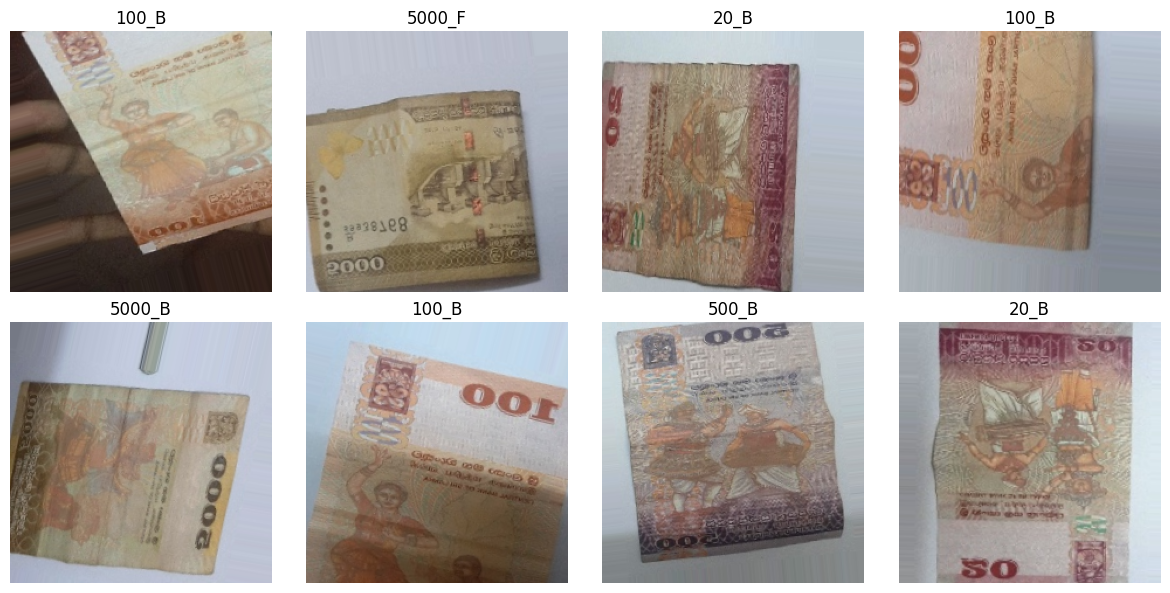

Calculated Class Weights: {0: np.float64(1.089962121212121), 1: np.float64(1.1697154471544715), 2: np.float64(0.940359477124183), 3: np.float64(1.1153100775193798), 4: np.float64(0.8198005698005698), 5: np.float64(0.8060224089635855), 6: np.float64(0.8060224089635855), 7: np.float64(0.826867816091954), 8: np.float64(0.9222756410256411), 9: np.float64(1.0657407407407407), 10: np.float64(1.089962121212121), 11: np.float64(2.3979166666666667)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    44,302,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,678,284 (170.43 MB)

 Trainable params: 44,677,388 (170.43 MB)

 Non-trainable params: 896 (3.50 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight as sklearn_class_weight
import seaborn as sns
import os

train_dir = "/content/dataset"

img_size = 224
batch_size = 32
SEED = 42

# Augmentation ONLY for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation/test — fixes augmentation leak on val data
val_test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

validation_generator = val_test_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

# Test set = same 20% split, no augmentation, no shuffle for consistent evaluation
test_generator = val_test_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of Classes:", num_classes)

images, labels = next(train_generator)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Calculate class weights to handle class imbalance
class_weights_array = sklearn_class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights_array))
print("Calculated Class Weights:", class_weights)

# Improved model: 3 Conv blocks + BatchNormalization + Dropout to fix overfitting
model = keras.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping restores best weights and stops when val_accuracy stops improving
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau halves the LR when val_loss plateaus
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights # Added class_weight here
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

test_loss, test_accuracy = model.evaluate(test_generator)
print("\nTest Accuracy:", test_accuracy)

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

images, labels = next(test_generator)

preds = model.predict(images)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    color = "green" if pred_classes[i] == true_classes[i] else "red"
    plt.title(f"P:{class_names[pred_classes[i]]}\nT:{class_names[true_classes[i]]}",
              color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

model.save("/content/drive/MyDrive/money_model_v3.h5")


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_uploaded_image():
    uploaded = files.upload()

    input_size = model.input_shape[1]

    for fn in uploaded.keys():
        img = image.load_img(fn, target_size=(input_size, input_size))
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        probabilities = predictions[0]


        top_3_indices = np.argsort(probabilities)[-3:][::-1]
        top_3_probs = probabilities[top_3_indices] * 100
        top_3_labels = [class_names[i] for i in top_3_indices]

        predicted_class = top_3_labels[0]
        confidence = top_3_probs[0]


        plt.figure(figsize=(12,4))


        plt.subplot(1,2,1)
        plt.imshow(img)
        plt.title("Uploaded Image")
        plt.axis("off")


        plt.subplot(1,2,2)
        plt.barh(top_3_labels[::-1], top_3_probs[::-1])
        plt.xlabel("Confidence (%)")
        plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")

        plt.tight_layout()
        plt.show()

        print("\nTop 3 Predictions:\n")
        for label, prob in zip(top_3_labels, top_3_probs):
            print(f"{label} : {prob:.2f}%")

predict_uploaded_image()

### Investigating Class Distribution

The model's tendency to predict only '5000_B' notes, even for different inputs, combined with the low overall accuracy, strongly suggests a class imbalance issue in the dataset. Let's visualize the distribution of images across all classes to confirm this.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming train_dir is already defined from previous cells
# train_dir = "/content/Dataset"

# Get class names (subfolder names) and count images in each
class_counts = {}
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Convert to DataFrame for easier plotting
df_class_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
df_class_counts = df_class_counts.sort_values('Count', ascending=False)

# Plot the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x='Class', y='Count', data=df_class_counts, palette='viridis')
plt.title('Distribution of Images per Class in Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Image counts per class:")
print(df_class_counts)
